# Capstone Project: Product Return Prediction for an E-Commerce Company

## Task 1 - Understand the business problem

Returns are one of the largest operational costs for an e-commerce marketplace. Every
returned order incurs reverse logistics, inspection, repackaging and refund costs. Our
task is to build a **binary classification** model that predicts, **before an order ships**,
whether it will be **returned**, so the business can act early (improve product info,
recommend prepaid payment, add quality checks, optimise logistics).

**Target variable:** `returned`  (`0` = not returned, `1` = returned)

This notebook follows the 12 tasks in the problem statement and also applies:
**outlier detection & removal**, **`class_weight='balanced'`** for class imbalance,


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
import joblib

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

## Load Data

> **Dataset note.** This notebook runs on `returns_dataset.csv` — a **programmatically
> generated** demonstration dataset (12,000 orders, a real ~30% return-rate imbalance, with
> `returned` a genuine noisy function of the features). It exists so the full preprocessing process
> (outlier removal + `class_weight='balanced'`) can be demonstrated. This is
> generated demonstration data, not a real-world measurement.

In [2]:
DATA_FILE = "dataset/returns_dataset.csv"
df = pd.read_csv(DATA_FILE)
print("Shape:", df.shape)
df.head()

Shape: (12000, 26)


,order_id,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,ORD100000,Beauty,Haircare,Brand_23,844.10,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,ORD100001,Toys,Educational,Brand_9,559.90,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0
2,ORD100002,Electronics,Laptops,Brand_21,1581.93,53.4,3.0,75.0,0,0,0.045,0.125,0.103,0.057,4.1,0.186,Marketplace Fulfilled,UPI,3,575.2,1,0,7,0,0,0
3,ORD100003,Electronics,Laptops,Brand_30,1301.55,25.3,3.8,57.0,0,1,0.066,0.119,0.085,0.064,3.9,0.133,Marketplace Fulfilled,Credit Card,4,164.5,0,1,9,0,1,0
4,ORD100004,Electronics,Laptops,Brand_15,1402.90,30.6,3.0,71.0,0,1,0.183,0.075,0.177,0.076,4.6,0.172,Marketplace Fulfilled,Credit Card,4,474.4,0,0,12,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  12000 non-null  str    
 1   product_category          12000 non-null  str    
 2   sub_category              12000 non-null  str    
 3   brand                     12000 non-null  str    
 4   product_price             12000 non-null  float64
 5   discount_percent          12000 non-null  float64
 6   product_rating            11760 non-null  float64
 7   review_count              11880 non-null  float64
 8   fragile_item              12000 non-null  int64  
 9   warranty_available        12000 non-null  int64  
 10  product_return_rate       12000 non-null  float64
 11  category_return_rate      12000 non-null  float64
 12  brand_return_rate         12000 non-null  float64
 13  defect_rate               12000 non-null  float64
 14  seller_rating    

## Task 2 - Exploratory Data Analysis (EDA)

### 2.1 Target distribution

In [4]:
counts = df["returned"].value_counts()
print(counts)

returned
0    8355
1    3645
Name: count, dtype: int64


returned
0    69.62
1    30.38
Name: proportion, dtype: float64


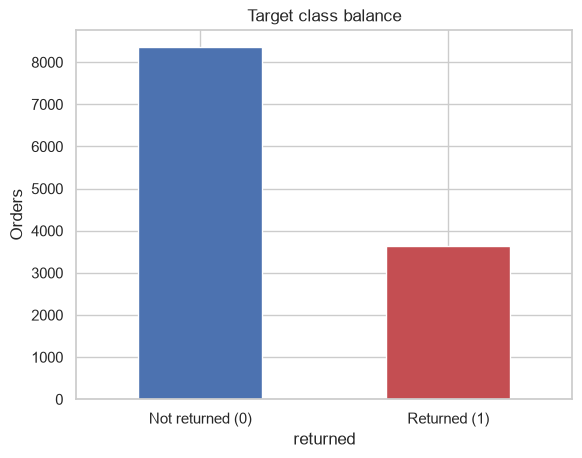

In [5]:
print((df["returned"].value_counts(normalize=True) * 100).round(2))
ax = counts.plot(kind="bar", color=["#4c72b0", "#c44e52"])
ax.set_xticklabels(["Not returned (0)", "Returned (1)"], rotation=0)
ax.set_title("Target class balance"); ax.set_ylabel("Orders")
plt.show()

The bar shows the class balance. Whenever the classes are uneven, Accuracy alone is
misleading, so we report Precision/Recall/F1 and handle imbalance with
**`class_weight='balanced'`** during model training.

### 2.2 Missing values

In [6]:
df.isna().sum()

order_id                      0
product_category              0
sub_category                  0
brand                         0
product_price                 0
discount_percent              0
product_rating              240
review_count                120
fragile_item                  0
warranty_available            0
product_return_rate           0
category_return_rate          0
brand_return_rate             0
defect_rate                   0
seller_rating               180
seller_return_rate            0
fulfillment_type              0
payment_method                0
quantity                      0
shipping_distance_km        120
delayed_delivery              0
wishlist_before_purchase      0
product_page_views            0
customer_support_calls        0
chat_interactions             0
returned                      0
dtype: int64

Four numeric columns have 1-2% missingness; imputed during preprocessing (Task 7).

### 2.3 Numeric summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_price,12000.0,964.063342,1678.771489,19.510,328.235,597.470,1105.395,64878.670
discount_percent,12000.0,33.567167,19.378304,0.000,16.800,33.500,50.400,67.000
product_rating,11760.0,3.886505,0.635664,1.600,3.500,3.900,4.300,5.000
review_count,11880.0,69.437205,18.446294,24.000,54.000,69.000,85.000,116.000
fragile_item,12000.0,0.197083,0.397812,0.000,0.000,0.000,0.000,1.000
warranty_available,12000.0,0.446500,0.497150,0.000,0.000,0.000,1.000,1.000
product_return_rate,12000.0,0.132522,0.069787,0.001,0.082,0.134,0.183,0.367
category_return_rate,12000.0,0.120377,0.049559,0.001,0.087,0.120,0.154,0.354
brand_return_rate,12000.0,0.131886,0.059397,0.010,0.090,0.135,0.176,0.322
defect_rate,12000.0,0.060629,0.042730,0.000,0.029,0.051,0.082,0.370


### 2.4 Categorical columns & a data-quality check

In [8]:
categorical_columns = ['product_category', 'sub_category', 'brand', 'fulfillment_type', 'payment_method']

for col in categorical_columns:
    print(df[col].value_counts())
    print()

product_category
Fashion        3413
Electronics    2601
Home           1816
Beauty         1453
Sports         1202
Books           910
Toys            605
Name: count, dtype: int64

sub_category
Mobiles           904
Audio             862
Laptops           835
Women             706
Accessories       684
Footwear          681
Men               673
Kids              669
Furniture         614
Kitchen           614
Decor             588
Haircare          505
Skincare          485
Makeup            463
Team Sports       439
Fitness           389
Outdoor           374
Non-Fiction       335
Fiction           288
Academic          287
Outdoor Play      220
Educational       195
Action Figures    190
Name: count, dtype: int64

brand
Brand_26    442
Brand_21    431
Brand_24    427
Brand_1     425
Brand_15    420
Brand_22    418
Brand_5     418
Brand_11    413
Brand_9     411
Brand_30    410
Brand_7     408
Brand_2     407
Brand_19    406
Brand_14    405
Brand_25    403
Brand_29    400
Brand_4 

`fulfillment_type` contains an **inconsistent value** `'marketplace fulfilled '`
(lowercase + trailing space) - fixed in Task 3.

### 2.5 Return rate by key categorical features

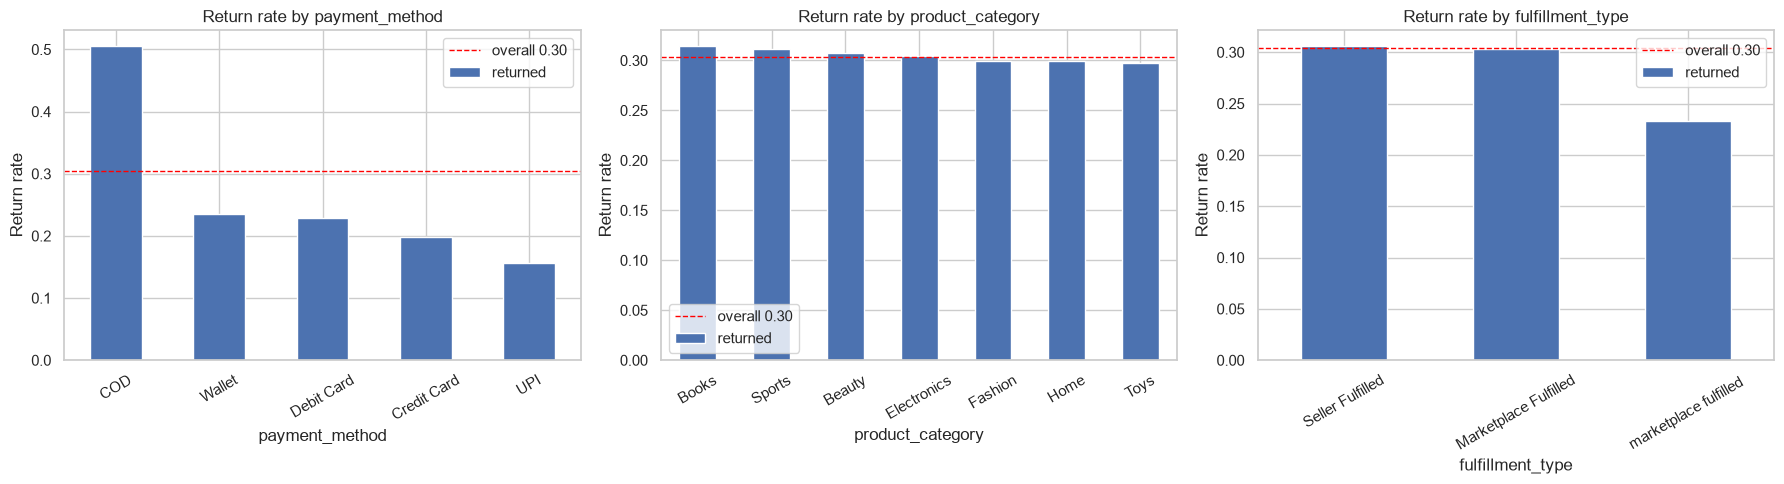

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
overall = df["returned"].mean()
for ax, col in zip(axes, ["payment_method", "product_category", "fulfillment_type"]):
    rate = df.groupby(col)["returned"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#4c72b0")
    ax.axhline(overall, color="red", ls="--", lw=1, label=f"overall {overall:.2f}")
    ax.set_title(f"Return rate by {col}"); ax.set_ylabel("Return rate")
    ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout(); plt.show()

Bars above the red line (overall average) flag higher-risk categories. Payment method
and brand tend to show the clearest separation.

### 2.6 Numeric distributions

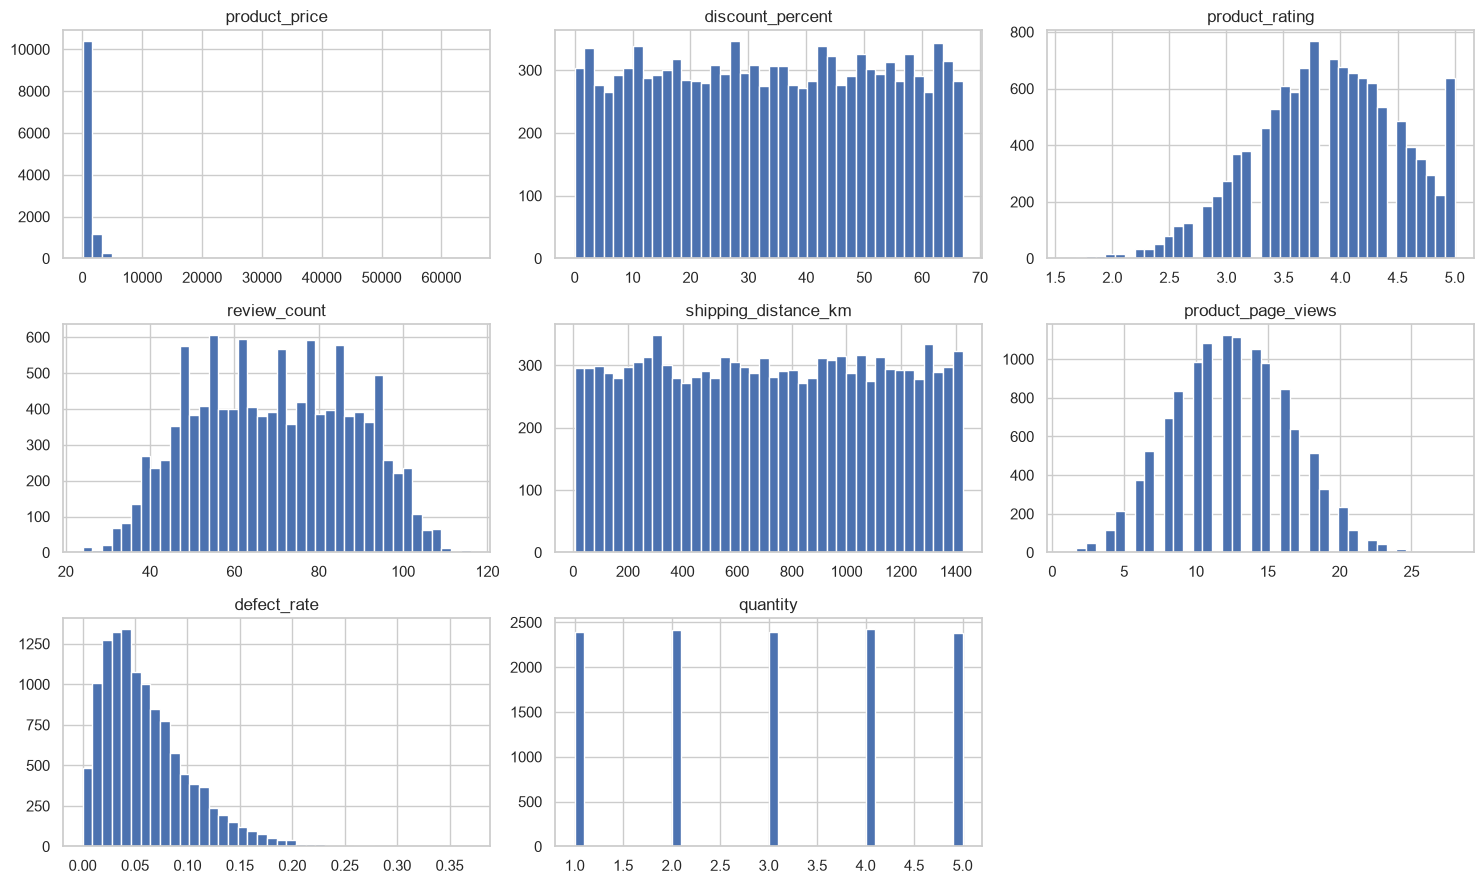

In [10]:
num_show = ["product_price", "discount_percent", "product_rating", "review_count",
            "shipping_distance_km", "product_page_views", "defect_rate", "quantity"]
df[num_show].hist(figsize=(15, 9), bins=40); plt.tight_layout(); plt.show()

Only `product_price` is genuinely right-skewed (skew ≈ 16; max 64,879 vs median 597) — this is the one column that benefits from a `log1p` transform. `review_count` (skew ≈ 0.01) and `product_page_views` (skew ≈ 0.08) are roughly symmetric, and `shipping_distance_km` (skew ≈ 0.00) is essentially **uniform**, so none of those three need a log transform.

### 2.7 Correlation with the target

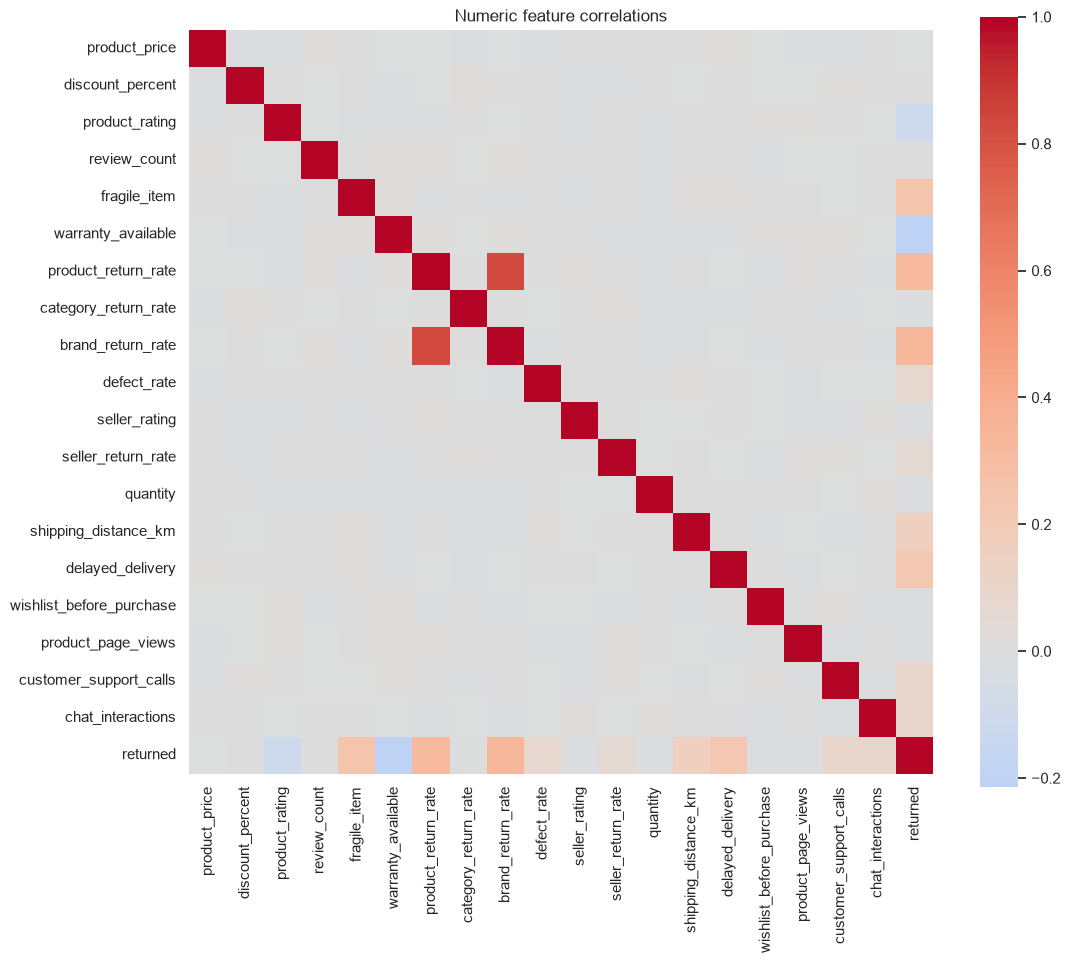

brand_return_rate           0.337
product_return_rate         0.313
fragile_item                0.258
delayed_delivery            0.229
warranty_available         -0.214
shipping_distance_km        0.162
product_rating             -0.110
customer_support_calls      0.094
chat_interactions           0.092
defect_rate                 0.074
seller_return_rate          0.059
product_page_views         -0.014
quantity                   -0.013
seller_rating              -0.010
discount_percent            0.009
wishlist_before_purchase   -0.009
category_return_rate       -0.006
review_count                0.006
product_price              -0.003
Name: returned, dtype: float64

In [11]:
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Numeric feature correlations"); plt.show()
corr["returned"].drop("returned").reindex(
    corr["returned"].drop("returned").abs().sort_values(ascending=False).index).round(3)

The `returned` row/column ranks how strongly each numeric feature relates to the
target. The historical return-rate columns, `defect_rate`, `fragile_item` and
`delayed_delivery` are typically among the strongest drivers.

## Task 3 - Handle missing values and inconsistent data

- Normalise the dirty `fulfillment_type` value.
- Drop `order_id` (unique identifier).
- Remove duplicate rows.
- Missing values imputed later inside the pipeline (leakage-safe).

In [12]:
df["fulfillment_type"].value_counts()

fulfillment_type
Marketplace Fulfilled     7193
Seller Fulfilled          4747
marketplace fulfilled       60
Name: count, dtype: int64

In [13]:
df_clean = df.copy()
df_clean["fulfillment_type"] = df_clean["fulfillment_type"].astype("string").str.strip().str.title()
df_clean["fulfillment_type"].value_counts()

fulfillment_type
Marketplace Fulfilled    7253
Seller Fulfilled         4747
Name: count, dtype: int64[pyarrow]

In [14]:
df_clean.head(2)

,order_id,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,ORD100000,Beauty,Haircare,Brand_23,844.1,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,ORD100001,Toys,Educational,Brand_9,559.9,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0


In [15]:
df_clean = df_clean.drop(columns=["order_id"])
df_clean.head(2)

,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,product_return_rate,category_return_rate,brand_return_rate,defect_rate,seller_rating,seller_return_rate,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,Beauty,Haircare,Brand_23,844.1,65.2,2.1,96.0,1,1,0.172,0.173,0.219,0.116,4.1,0.128,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,Toys,Educational,Brand_9,559.9,30.1,4.1,87.0,0,1,0.168,0.125,0.155,0.031,4.2,0.171,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0


In [16]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {before - len(df_clean)} duplicates. Shape: {df_clean.shape}")


Dropped 0 duplicates. Shape: (12000, 25)


## Task 5 - Feature Engineering

Domain features from pre-shipment information, computed per-row (leakage-safe).

In [17]:
def add_features(data):
    d = data.copy()
    # Combined distress signal: a customer who BOTH called support and used chat is more
    # likely to return than one who did just one (corr w/ target 0.13 vs 0.09 each).
    # total = customer_support_calls + chat_interactions EXACTLY, so we drop the two raw
    # counts. Keeping all three would be perfect multicollinearity (design-matrix condition
    # number ~1e15) and split the coefficient across three columns, muddying the Task 10
    # feature-importance readout. This makes total_support_contacts a true *replacement*.
    d["total_support_contacts"] = d["customer_support_calls"] + d["chat_interactions"]
    d = d.drop(columns=["customer_support_calls", "chat_interactions"])
    # product_price is the ONLY heavily right-skewed numeric column (skew ~16, max 64,879 vs
    # median 597). log1p tames the tail. We REPLACE raw product_price with its log so the two
    # are not collinear (raw price and log price correlate 0.62; keeping both hurts the
    # scale-sensitive Logistic Regression).
    d["log_price"] = np.log1p(d["product_price"])
    d = d.drop(columns=["product_price"])
    return d

df_feat = add_features(df_clean)
df_feat.to_csv("dataset/cleaned_returns.csv", index=False)
print("Saved cleaned + engineered dataset -> dataset/cleaned_returns.csv", df_feat.shape)
new_cols = ["total_support_contacts", "log_price"]
df_feat[new_cols].describe().T

Saved cleaned + engineered dataset -> dataset/cleaned_returns.csv (12000, 24)


,count,mean,std,min,25%,50%,75%,max
total_support_contacts,12000.0,0.793000,0.888285,0.000000,0.000000,1.000000,1.000000,6.00000
log_price,12000.0,6.407976,0.922538,3.020913,5.796772,6.394376,7.008862,11.08029


## Task 6 - Train/Test Split

Stratified 80/20. Outlier removal is computed on the **training set only**.

In [18]:
X = df_feat.drop(columns=["returned"])
y = df_feat["returned"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (9600, 23) Test: (2400, 23)


## Outlier Detection & Removal (reference technique)

We visualise the skewed continuous columns with box plots, then remove extreme outliers
from the **training set only** (beyond Q3 + 3*IQR) so the model is not distorted by a few
extreme values. The test set is left untouched to reflect real incoming data.

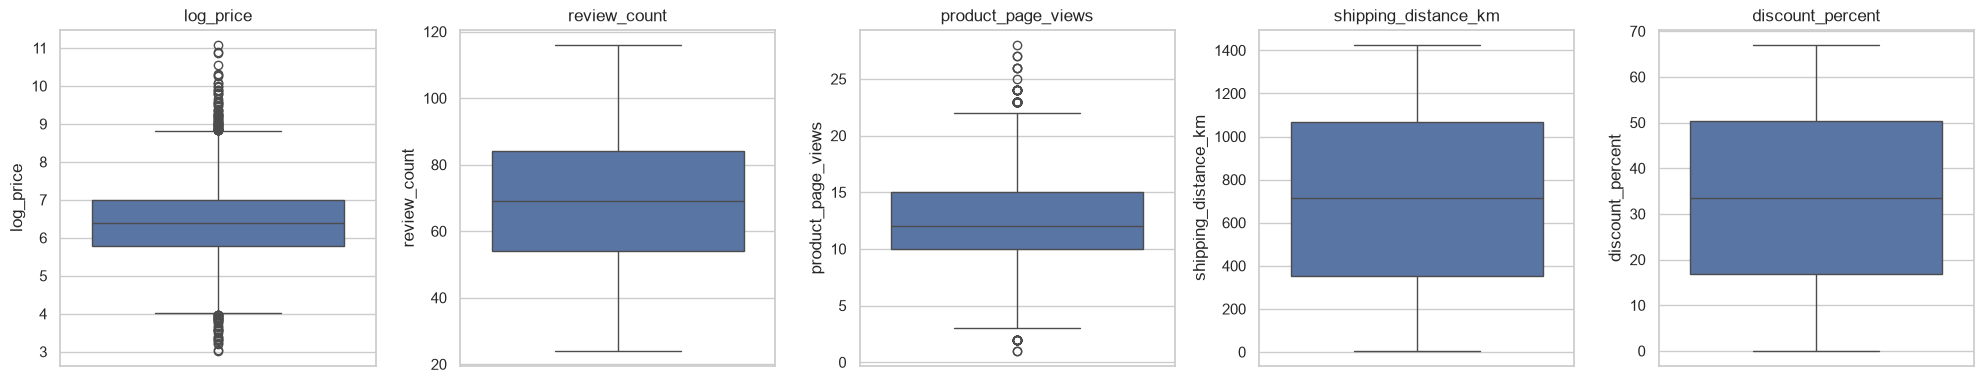

In [19]:
# raw product_price was replaced by log_price in feature engineering, so we inspect log_price here
box_cols = ["log_price", "review_count", "product_page_views",
            "shipping_distance_km", "discount_percent"]
fig, axes = plt.subplots(1, len(box_cols), figsize=(20, 4))
for ax, c in zip(axes, box_cols):
    sns.boxplot(y=X_train[c], ax=ax, color="#4c72b0"); ax.set_title(c)
plt.tight_layout(); plt.show()

In [20]:
# Remove extreme outliers (Q3 + 3*IQR) on log_price - training set only.
# NOTE: with product_price already log-transformed, the tail is tamed, so this now removes
# very few rows. review_count / product_page_views are near-symmetric and bounded, so IQR
# outlier removal on them is not warranted (it would just clip legitimate values). We keep
# the step on log_price alone as a light, defensible guard against any residual extremes.
outlier_cols = ["log_price"]
mask = pd.Series(True, index=X_train.index)
for c in outlier_cols:
    q1, q3 = X_train[c].quantile(0.25), X_train[c].quantile(0.75)
    upper = q3 + 3 * (q3 - q1)
    mask &= X_train[c] <= upper
removed = (~mask).sum()
X_train, y_train = X_train[mask], y_train[mask]
print(f"Removed {removed} extreme-outlier rows from training set. New train shape: {X_train.shape}")

Removed 3 extreme-outlier rows from training set. New train shape: (9597, 23)


## Task 7 - Preprocessing & Task 4 - Encoding

All features from feature engineering are used (no feature selection step). Preprocessing
is done in plain pandas:
- **Numeric** → median imputation + standard scaling.
- **Categorical** → one-hot encoding with `pd.get_dummies()`.

Imputation and scaling are fit on training data only (no leakage).

In [21]:
# Identify feature groups
binary_flags = ["fragile_item", "warranty_available", "delayed_delivery", "wishlist_before_purchase"]
categorical_features = ["product_category", "sub_category", "brand", "fulfillment_type", "payment_method"]
numeric_features = [c for c in X_train.columns if c not in binary_flags + categorical_features]

all_features = numeric_features + binary_flags  # continuous + binary
print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Binary flags ({len(binary_flags)}):", binary_flags)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

Numeric features (14): ['discount_percent', 'product_rating', 'review_count', 'product_return_rate', 'category_return_rate', 'brand_return_rate', 'defect_rate', 'seller_rating', 'seller_return_rate', 'quantity', 'shipping_distance_km', 'product_page_views', 'total_support_contacts', 'log_price']
Binary flags (4): ['fragile_item', 'warranty_available', 'delayed_delivery', 'wishlist_before_purchase']
Categorical features (5): ['product_category', 'sub_category', 'brand', 'fulfillment_type', 'payment_method']


In [22]:
# 1. Impute missing values (median from training set)
train_medians = X_train[all_features].median().to_dict()
X_train[all_features] = X_train[all_features].fillna(train_medians)
X_test[all_features] = X_test[all_features].fillna(train_medians)

# 2. Scale numeric features
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# 3. One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=categorical_features, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_features, dtype=int)

# Align columns (test may have missing/extra categories)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

model_columns = list(X_train.columns)
print(f"Final feature count: {len(model_columns)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Final feature count: 85
Train: (9597, 85), Test: (2400, 85)


## Task 8 - Train multiple classification models

Four models, each using **`class_weight='balanced'`** (or `scale_pos_weight` for XGBoost)
to handle the ~30% class imbalance. Models are trained directly on the preprocessed data.

In [23]:
# Calculate scale_pos_weight for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

fitted = {}
for name, est in models.items():
    est.fit(X_train, y_train)
    fitted[name] = est
    print("Trained:", name)

Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest


Trained: XGBoost


## Task 9 - Compare model performance

In [24]:
def evaluate(model, X, y):
    pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
    }

comparison = pd.DataFrame({n: evaluate(m, X_test, y_test) for n, m in fitted.items()}).T
comparison = comparison.sort_values("F1", ascending=False)
comparison.round(4)

,Accuracy,Precision,Recall,F1
Logistic Regression,0.8558,0.7194,0.8615,0.7840
XGBoost,0.8500,0.7215,0.8244,0.7695
Random Forest,0.8488,0.7500,0.7531,0.7515
Decision Tree,0.7800,0.6345,0.6502,0.6423


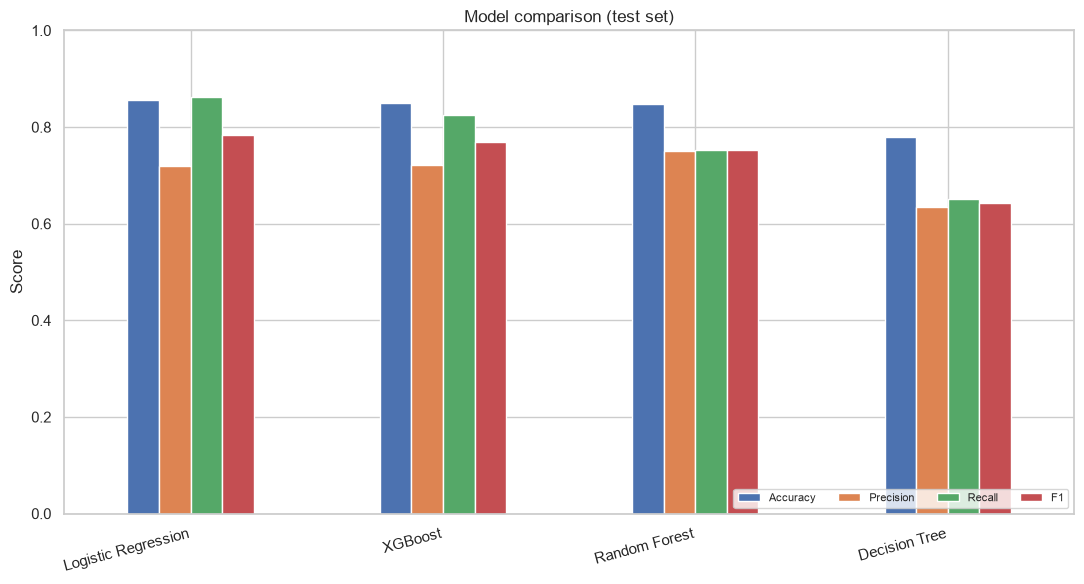

In [25]:
comparison.plot(kind="bar", figsize=(11, 6)); plt.title("Model comparison (test set)")
plt.ylabel("Score"); plt.ylim(0, 1); plt.legend(loc="lower right", ncol=4, fontsize=8)
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

### Why Precision and Recall matter more than Accuracy

When classes are uneven, a model that always predicts the majority class scores high
accuracy while catching none of the minority class. **Recall** captures value (each missed
return costs the full reverse-logistics + refund); **Precision** controls the cost of
wasted preventive actions. The business favours higher recall; **F1**/**ROC-AUC** summarise
the balance.

### Select the best model

The best model (by F1) is carried forward to tuning. Class imbalance is handled by
**`class_weight='balanced'`** throughout.

In [26]:
best_name = comparison.index[0]
print("Best model by F1:", best_name, "| imbalance: class_weight='balanced'")

Best model by F1: Logistic Regression | imbalance: class_weight='balanced'


In [27]:
final_model = fitted[best_name]
tuned_metrics = evaluate(final_model, X_test, y_test)
print(f"Final {best_name} (class_weight='balanced') test metrics:")
for k, v in tuned_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

Final Logistic Regression (class_weight='balanced') test metrics:
  Accuracy  : 0.8558
  Precision : 0.7194
  Recall    : 0.8615
  F1        : 0.7840


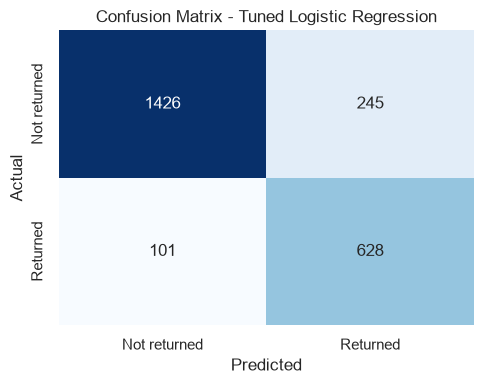

              precision    recall  f1-score   support

Not returned     0.9339    0.8534    0.8918      1671
    Returned     0.7194    0.8615    0.7840       729

    accuracy                         0.8558      2400
   macro avg     0.8266    0.8574    0.8379      2400
weighted avg     0.8687    0.8558    0.8591      2400



In [28]:
cm = confusion_matrix(y_test, final_model.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not returned", "Returned"], yticklabels=["Not returned", "Returned"])
plt.title(f"Confusion Matrix - Tuned {best_name}"); plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()
print(classification_report(y_test, final_model.predict(X_test),
                            target_names=["Not returned", "Returned"], digits=4))

## Task 10 - Interpret the model using feature importance

We extract feature importances (or absolute coefficients for Logistic Regression)
from the trained model and plot the top 20.

In [29]:
final_model.coef_

array([[ 7.47591581e-03, -5.23863182e-01,  2.86142806e-03,
         2.87249047e+00, -2.16164193e+00,  4.22362864e-01,
        -1.03250519e-02,  3.58610575e-01,  3.46459909e-01,
        -2.84211602e-02,  2.72236855e-01, -2.00838663e-02,
         7.45413895e-01,  2.56432673e+00, -3.65018408e-02,
        -3.57144034e-02,  6.69394360e-01,  2.81393889e-03,
        -1.07208073e-01, -7.61715455e-02, -1.02085444e-01,
        -1.37941656e-01,  1.69516589e-02, -2.01794446e-01,
        -4.43904529e-02,  6.62460028e-02,  9.42882293e-02,
        -3.11896120e-01, -1.18549756e-01, -7.19107398e-02,
         2.95339819e-01,  1.17277612e-01, -5.17672415e-02,
         3.05874589e-02,  1.97136668e-01, -1.73876352e-01,
        -7.90088496e-02, -1.08274269e-01, -1.49663419e-01,
         9.39261936e-02, -2.36474426e-01,  1.66127732e-01,
        -2.59695160e-01, -1.37068666e-01, -2.78341521e-02,
        -2.72579151e-02, -1.29585388e-02,  5.26659313e-02,
         3.37010777e-01, -1.37046457e+00,  1.42882942e+0

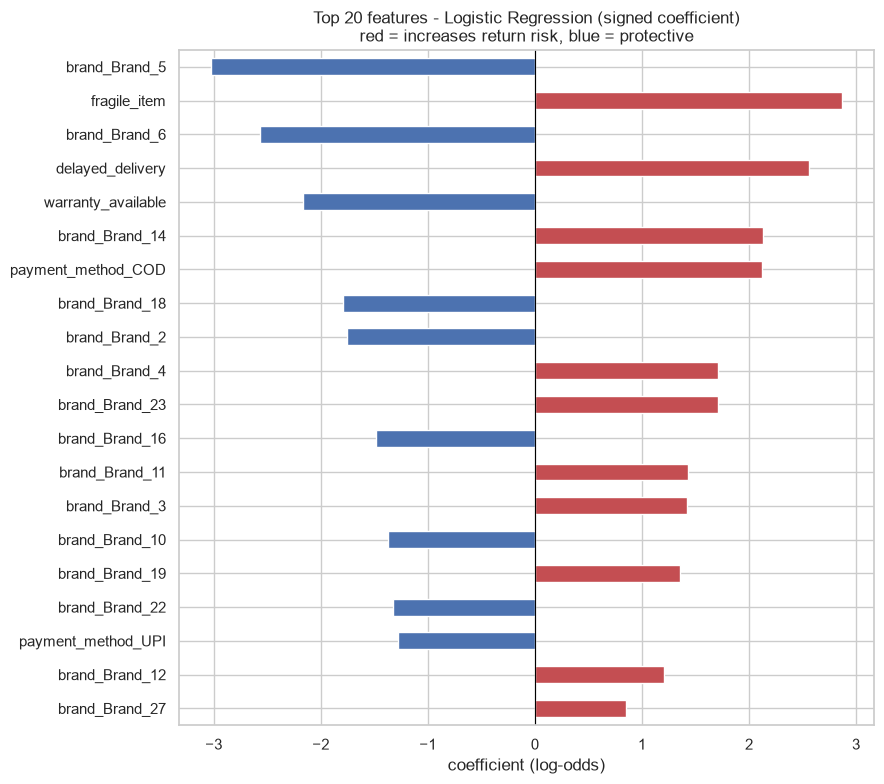

brand_Brand_5        -3.0272
fragile_item          2.8725
brand_Brand_6        -2.5675
delayed_delivery      2.5643
warranty_available   -2.1616
brand_Brand_14        2.1296
payment_method_COD    2.1233
brand_Brand_18       -1.7904
brand_Brand_2        -1.7540
brand_Brand_4         1.7075
brand_Brand_23        1.7068
brand_Brand_16       -1.4866
brand_Brand_11        1.4288
brand_Brand_3         1.4218
brand_Brand_10       -1.3705
brand_Brand_19        1.3553
brand_Brand_22       -1.3290
payment_method_UPI   -1.2751
brand_Brand_12        1.2058
brand_Brand_27        0.8482
dtype: float64

In [30]:
# Rank features by coefficient MAGNITUDE (so the strongest predictors are shown), but keep
# the SIGN via colour: red = pushes toward a return, blue = protective (pushes away).
# This is better than plotting raw signed values and taking head(20), which would silently
# drop the strongest features when their coefficient is negative.
imp = pd.Series(final_model.coef_[0], index=model_columns)
top = imp.reindex(imp.abs().sort_values(ascending=False).index).head(20)
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in top]

plt.figure(figsize=(9, 8))
top[::-1].plot(kind="barh", color=colors[::-1])
plt.axvline(0, color="black", lw=0.8)
plt.title(f"Top 20 features - {best_name} (signed coefficient)\nred = increases return risk, blue = protective")
plt.xlabel("coefficient (log-odds)")
plt.tight_layout(); plt.show()
top.round(4)

## Task 11 - Save the final model using joblib

We save the trained model along with the scaler, feature lists, and metadata needed for
inference. The saved bundle contains everything needed to preprocess a raw order and predict.

In [31]:
# Feature importance dict for the API
fi_values = np.abs(final_model.coef_[0])
fi_series = pd.Series(fi_values, index=model_columns).sort_values(ascending=False)
feature_importance = [{"feature": k, "importance": round(float(v), 6)}
                      for k, v in fi_series.head(20).items()]

model_data = {
    "model": final_model,
    "model_name": best_name,
    "scaler": scaler,
    "model_columns": model_columns,
    "numeric_features": numeric_features,
    "binary_flags": binary_flags,
    "categorical_features": categorical_features,
    "train_medians": train_medians,
    "metrics": tuned_metrics,
    "feature_importance": feature_importance,
    "threshold": 0.5,
}
joblib.dump(model_data, "artifacts/model_data.joblib")
print("Saved -> artifacts/model_data.joblib")

Saved -> artifacts/model_data.joblib


In [32]:
loaded = joblib.load("artifacts/model_data.joblib")
sample = X_test.head(5)
proba = loaded["model"].predict_proba(sample)[:, 1]
pd.DataFrame({"return_probability": proba.round(3),
              "predicted_returned": (proba >= loaded["threshold"]).astype(int)})

,return_probability,predicted_returned
0,0.069,0
1,0.696,1
2,0.741,1
3,0.228,0
4,0.112,0


## Model Evaluation Report (deliverable)

In [33]:
print("=" * 60)
print("MODEL EVALUATION REPORT - Product Return Prediction")
print("=" * 60)
print(f"Orders: {df.shape[0]} | return rate: {y.mean():.1%}")
print(f"After outlier removal, train rows: {len(y_train)} | test rows: {len(y_test)}")
print(f"Total model features: {len(model_columns)}")
print(f"  Numeric: {len(numeric_features)} | Binary flags: {len(binary_flags)} | Categorical (encoded): {len(categorical_features)}")
print(f"\nModel comparison (all with class_weight='balanced'), sorted by F1:")
print(comparison.round(4).to_string())
print(f"\nFinal model: {best_name}")
print("\nFinal test metrics:")
for k, v in tuned_metrics.items():
    print(f"  {k:10s}: {v:.4f}")
print("\nArtifacts: dataset/cleaned_returns.csv, artifacts/model_data.joblib")

MODEL EVALUATION REPORT - Product Return Prediction
Orders: 12000 | return rate: 30.4%
After outlier removal, train rows: 9597 | test rows: 2400
Total model features: 85
  Numeric: 14 | Binary flags: 4 | Categorical (encoded): 5

Model comparison (all with class_weight='balanced'), sorted by F1:
                     Accuracy  Precision  Recall      F1
Logistic Regression    0.8558     0.7194  0.8615  0.7840
XGBoost                0.8500     0.7215  0.8244  0.7695
Random Forest          0.8488     0.7500  0.7531  0.7515
Decision Tree          0.7800     0.6345  0.6502  0.6423

Final model: Logistic Regression

Final test metrics:
  Accuracy  : 0.8558
  Precision : 0.7194
  Recall    : 0.8615
  F1        : 0.7840

Artifacts: dataset/cleaned_returns.csv, artifacts/model_data.joblib
